In [1]:
import cv2
import os 
from collections import defaultdict
from PIL import Image
import math
import matplotlib.pyplot as plt
import numpy as np

In [39]:
dire = "../data"
ab = defaultdict()
for filename in os.listdir(dire):
    # print(dire)
    # print(filename)
    if filename != ".DS_Store":
        img = Image.open(f"{dire}/{filename}")
        size_x_y = img.size
        if size_x_y not in ab.keys():
            ab[size_x_y] = 1
        else:
            ab[size_x_y] +=1



KeyboardInterrupt: 

In [2]:



# Use the defaultdict to initialize counts to 0 automatically
aspect_ratio_counts = defaultdict(int) 

dire = "../data"

for filename in os.listdir(dire):
    if filename != ".DS_Store":
        try:
            img = Image.open(f"{dire}/{filename}")
            width, height = img.size

            # 1. Calculate the Greatest Common Divisor (GCD)
            common_divisor = math.gcd(width, height)

            # 2. Simplify the ratio
            ratio_x = width // common_divisor
            ratio_y = height // common_divisor

            # 3. Create a standardized string key (e.g., "16:9")
            aspect_ratio_key = f"{ratio_x}:{ratio_y}"
            
            # 4. Increment the count for that ratio
            aspect_ratio_counts[aspect_ratio_key] += 1
            
        except Exception as e:
            print(f"Skipping file {filename} due to error: {e}")

# Now, aspect_ratio_counts is ready to be plotted using the code from my *first* answer.
print(aspect_ratio_counts)

defaultdict(<class 'int'>, {'26:69': 1, '63:58': 18, '37:49': 12, '41:38': 33, '27:31': 41, '591:181': 1, '1:1': 901, '83:43': 7, '13:17': 35, '211:137': 1, '159:100': 1, '61:77': 6, '74:61': 17, '33:35': 22, '185:58': 2, '57:65': 8, '58:43': 12, '163:100': 5, '8:5': 44, '3:2': 191, '13:12': 68, '31:48': 10, '21:19': 40, '84:71': 6, '18:19': 28, '16:11': 39, '83:104': 2, '131:94': 2, '22:15': 30, '52:57': 15, '93:53': 2, '47:40': 27, '43:49': 18, '9:10': 74, '44:49': 31, '68:33': 10, '21:13': 27, '17:12': 32, '98:59': 1, '33:50': 9, '47:14': 2, '64:35': 7, '9:14': 27, '15:17': 43, '59:60': 13, '31:25': 20, '43:47': 16, '52:47': 10, '43:40': 20, '25:23': 35, '29:17': 20, '2:1': 195, '39:46': 19, '27:23': 31, '116:103': 6, '68:65': 7, '23:16': 31, '31:20': 17, '3:5': 36, '47:96': 4, '31:35': 21, '116:47': 2, '21:22': 46, '49:47': 19, '127:92': 1, '15:13': 39, '5:7': 50, '67:55': 5, '26:15': 13, '57:58': 11, '52:51': 18, '105:34': 5, '16:15': 58, '11:20': 4, '78:41': 7, '33:28': 22, '44:6

In [28]:
print(ab)

defaultdict(None, {(26, 69): 1, (63, 58): 14, (74, 98): 5, (41, 38): 18, (27, 31): 14, (37, 37): 18, (83, 43): 5, (39, 51): 18, (211, 137): 1, (159, 100): 1, (61, 77): 5, (74, 61): 13, (185, 58): 2, (57, 65): 8, (58, 43): 10, (78, 52): 5, (52, 48): 9, (31, 48): 6, (63, 57): 9, (84, 71): 5, (36, 38): 8, (40, 25): 6, (32, 22): 4, (83, 104): 2, (131, 94): 2, (66, 45): 10, (29, 29): 10, (52, 57): 11, (93, 53): 2, (43, 49): 9, (44, 49): 25, (68, 33): 10, (168, 104): 1, (68, 48): 4, (98, 59): 1, (33, 50): 4, (47, 14): 1, (64, 35): 6, (60, 68): 5, (118, 120): 1, (31, 25): 7, (43, 47): 10, (52, 47): 8, (82, 82): 8, (75, 69): 3, (88, 44): 5, (39, 46): 18, (27, 23): 8, (116, 103): 5, (68, 65): 7, (31, 20): 1, (53, 53): 14, (39, 65): 3, (31, 35): 13, (116, 47): 2, (42, 44): 20, (49, 47): 10, (127, 92): 1, (45, 39): 10, (35, 49): 2, (67, 55): 5, (130, 75): 1, (57, 58): 9, (52, 51): 12, (105, 34): 3, (32, 30): 14, (55, 100): 1, (78, 41): 5, (66, 56): 9, (44, 69): 2, (51, 78): 1, (93, 55): 3, (87, 7

In [6]:
def plot_hist_of_ratio(dict_name):
    # --- CONFIGURATION ---
    # 1. SET THE NUMBER OF BINS HERE TO TEST DIFFERENT VALUES
    N_BINS = 60
    # ---------------------


    # 1. Transform the aggregated data (counts) into a list of individual numerical ratios.
    numerical_ratios = []
    # Also create a map from numerical ratio (float) to string ratio (e.g., 1.777 -> "16:9")
    ratio_map = {} 

    for ratio_str, count in dict_name.items():
        if ':' in ratio_str:
            try:
                width_str, height_str = ratio_str.split(':')
                width = float(width_str)
                height = float(height_str)
                
                if height != 0:
                    numerical_ratio = width / height
                else:
                    continue 
                    
            except ValueError:
                continue
        else:
            try:
                numerical_ratio = float(ratio_str)
            except ValueError:
                continue
                
        # Add the numerical ratio to the list 'count' times
        numerical_ratios.extend([numerical_ratio] * count)
        
        # Populate the dynamic ratio map for labeling (rounded to 3 decimal places for matching)
        rounded_ratio = round(numerical_ratio, 3)
        # Prefer the string ratio over numerical placeholder if there's a collision
        ratio_map[rounded_ratio] = ratio_str 


    # 2. Create the Histogram
    plt.figure(figsize=(12, 7))

    # Use np.histogram to calculate bin edges
    hist_counts, bin_edges = np.histogram(numerical_ratios, bins=N_BINS) 

    # Plot the histogram
    plt.hist(numerical_ratios, bins=bin_edges, edgecolor='black', alpha=0.7, color='navy')

    # 3. Dynamic X-axis Labeling (using only input ratios)

    # Collect all unique numerical ratios present in the data (rounded for clean matching)
    data_ratios_rounded = sorted(ratio_map.keys())

    # Set tick positions: use only the unique data points for precise labeling
    tick_positions = data_ratios_rounded 
    tick_labels = [ratio_map[pos] for pos in tick_positions]

    # Prepare final unique ticks and labels (filtering for non-overlapping labels)
    unique_ticks = []
    unique_labels = []
    # Set a dynamic distance based on the range and number of bins
    data_range = np.max(numerical_ratios) - np.min(numerical_ratios)
    min_distance = data_range / N_BINS * 1.5 # A distance of about 1.5 bin widths

    if tick_positions:
        unique_ticks.append(tick_positions[0])
        unique_labels.append(tick_labels[0])

        for i in range(1, len(tick_positions)):
            if tick_positions[i] - unique_ticks[-1] > min_distance:
                unique_ticks.append(tick_positions[i])
                unique_labels.append(tick_labels[i])
            # If they overlap, and the new label is a common/simpler ratio, we can replace the last one (optional)
            # We will stick to simply ensuring minimum distance to keep the plot clean.

    # Apply the dynamic ticks and labels
    plt.xticks(unique_ticks, unique_labels, rotation=45, ha='right', fontsize=10)

    # 4. Add remaining formatting
    plt.xlabel("Aspect Ratio", fontsize=12)
    plt.ylabel("Frequency (Count of Images)", fontsize=12)
    plt.title(f"Histogram of Image Aspect Ratios (Bins: {N_BINS})", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # 5. Save the plot
    plt.savefig("aspect_ratio_histogram_dynamic.png")
    print("Histogram saved as 'aspect_ratio_histogram_dynamic.png'")

Histogram saved as 'aspect_ratio_histogram_dynamic.png'


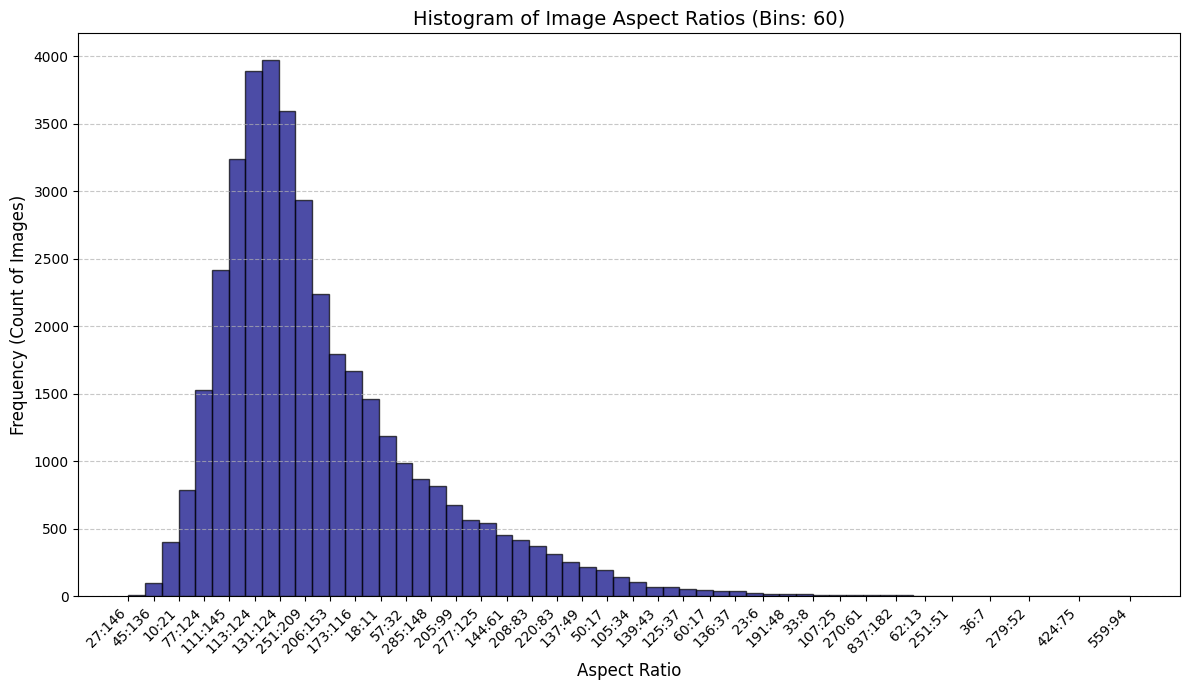

In [7]:
plot_hist_of_ratio(aspect_ratio_counts)

now for the filtered data

In [12]:

def from_img_path(img_path):
    # --- CONFIGURATION ---
    # 1. SET THE PATH TO YOUR LIST OF IMAGE PATHS (.txt file from the previous script)
    # Option A: Kept Data
    IMAGE_PATHS_FILE = img_path
    # Option B: Filtered Out Data (Uncomment this and comment A to switch)
    # IMAGE_PATHS_FILE = "../mahala_median/filtered_out_image_paths.txt"
    # ---------------------

    aspect_ratio_counts_filtered = defaultdict(int)

    # 1. Read all image paths from the text file
    try:
        with open(IMAGE_PATHS_FILE, 'r') as f:
            # Read lines, strip whitespace (including newline), and filter out empty lines
            image_paths = [line.strip() for line in f if line.strip()]
    except FileNotFoundError:
        print(f"❌ Error: The file {IMAGE_PATHS_FILE} was not found. Please check the path.")
        image_paths = []

    print(f"Processing {len(image_paths)} image paths from {IMAGE_PATHS_FILE}...")


    # 2. Iterate over the list of paths
    for image_path in image_paths:
        # Use the full path read from the file directly with Image.open()
        try:
            # Check if the path exists before attempting to open the image
            if not os.path.exists(image_path):
                print(f"Skipping file: Path does not exist: {image_path}")
                continue

            img = Image.open(image_path)
            width, height = img.size # size is returned as (width, height)

            # 3. Calculate the Greatest Common Divisor (GCD)
            common_divisor = math.gcd(width, height)

            # 4. Simplify the ratio
            ratio_x = width // common_divisor
            ratio_y = height // common_divisor

            # 5. Create a standardized string key (e.g., "16:9")
            aspect_ratio_key = f"{ratio_x}:{ratio_y}"
            
            # 6. Increment the count for that ratio
            aspect_ratio_counts_filtered[aspect_ratio_key] += 1
            
        except Exception as e:
            print(f"Skipping file {image_path} due to error: {e}")

    print("\nAspect Ratio Counts (Ready for Histogram Plotting):")
    return(dict(aspect_ratio_counts_filtered))

In [14]:
aspect_ratio_counts_kept = from_img_path("../mahala_median/kept_image_paths.txt")
aspect_ratio_counts_deleted = from_img_path("../mahala_median/filtered_out_image_paths.txt")

Processing 29047 image paths from ../mahala_median/kept_image_paths.txt...

Aspect Ratio Counts (Ready for Histogram Plotting):
Processing 9525 image paths from ../mahala_median/filtered_out_image_paths.txt...

Aspect Ratio Counts (Ready for Histogram Plotting):


Histogram saved as 'aspect_ratio_histogram_dynamic.png'


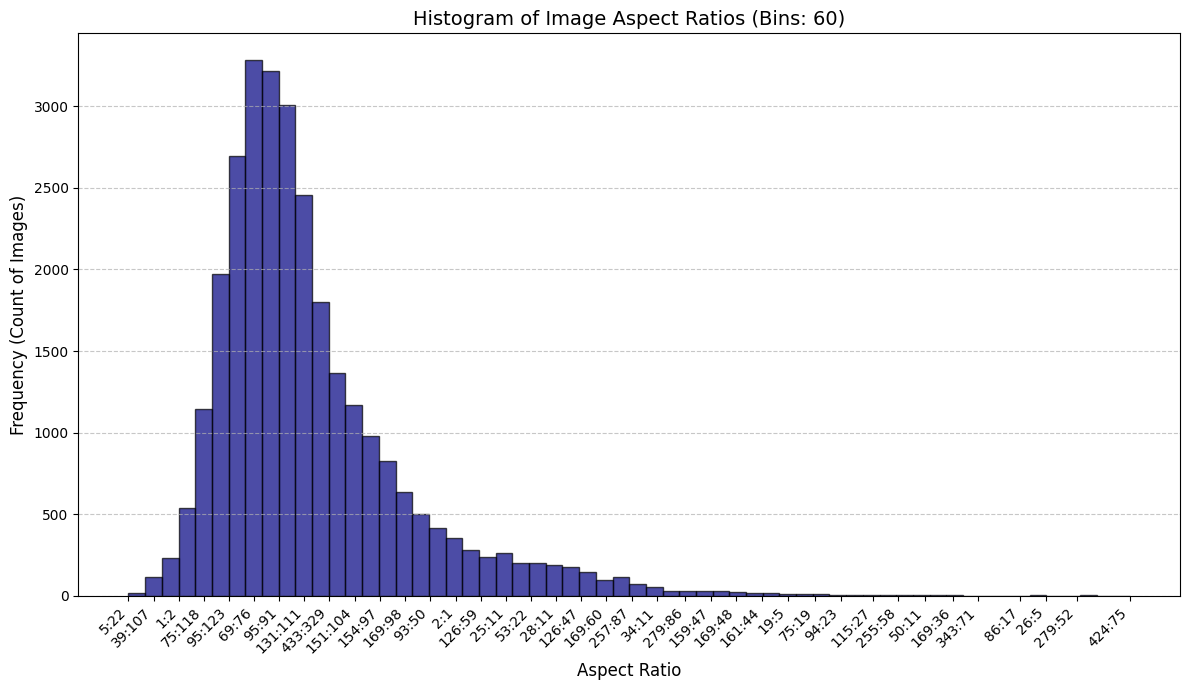

In [15]:
plot_hist_of_ratio(aspect_ratio_counts_kept)

Histogram saved as 'aspect_ratio_histogram_dynamic.png'


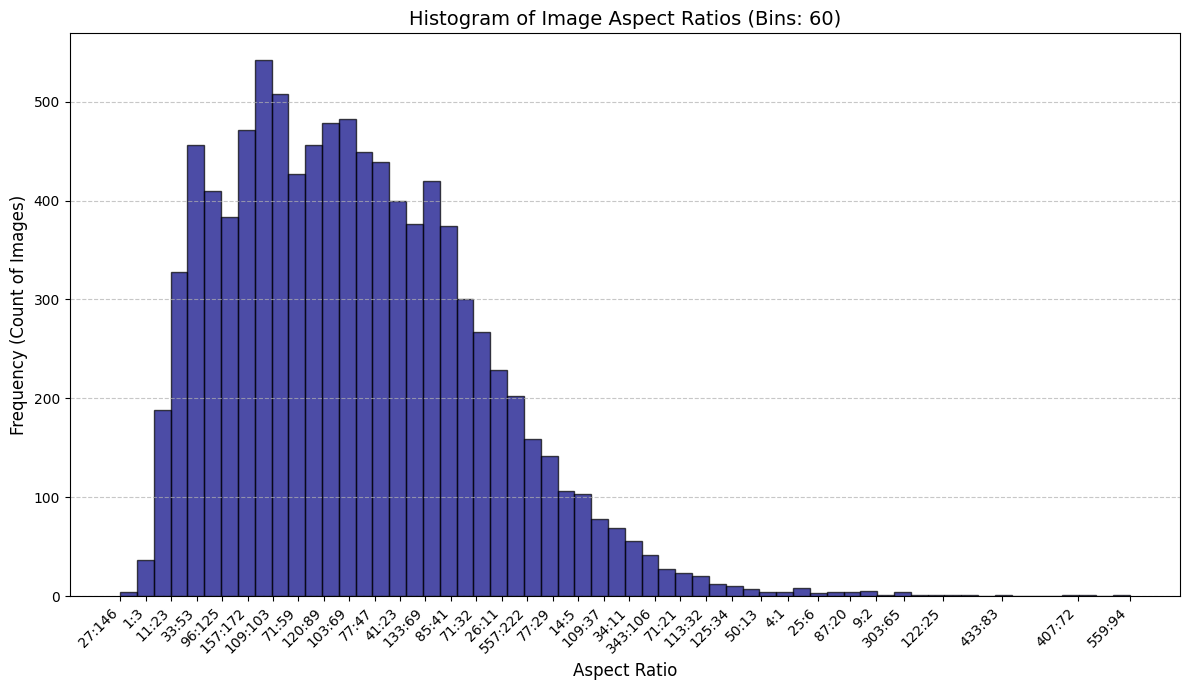

In [16]:
plot_hist_of_ratio(aspect_ratio_counts_deleted)

plot all three overlapping 

✅ Overlapping histogram saved as 'overlapping_aspect_ratio_histograms_labeled.png'


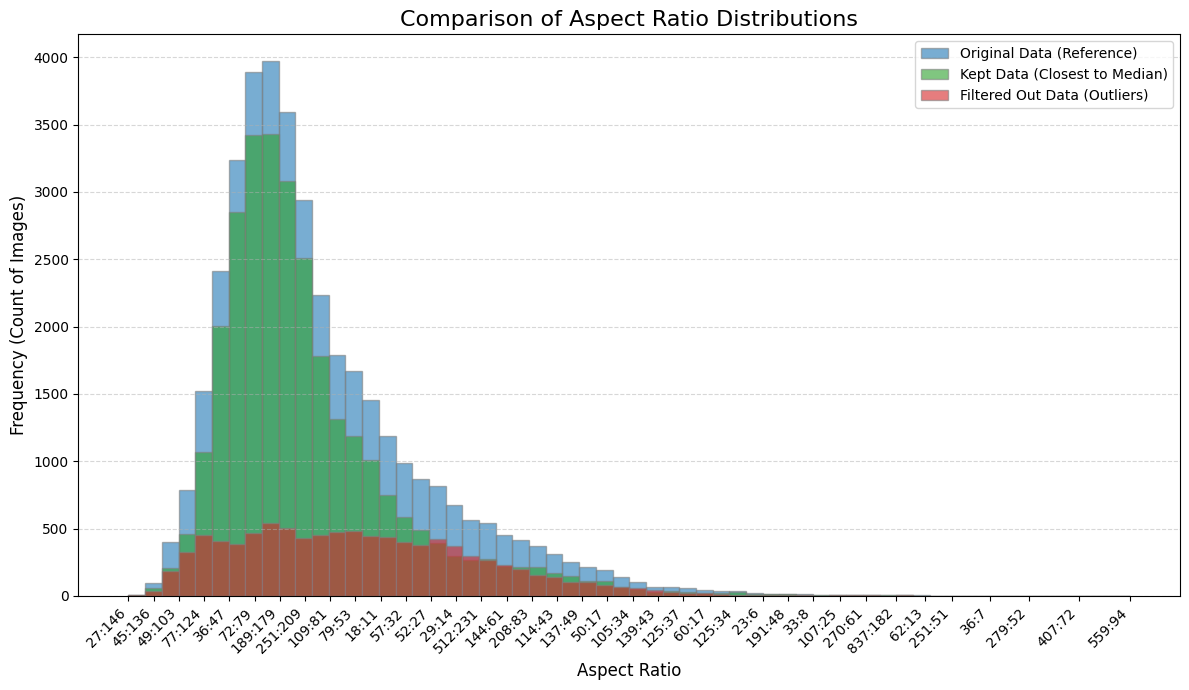

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import math

# --- 1. DATA TRANSFORMATION FUNCTION ---

def transform_ratio_dict_to_numerical_list(ratio_counts_dict):
    """
    Converts a ratio count dictionary (str: int) into an unrolled list of 
    numerical ratios (float), and collects the numerical-to-string mapping.
    
    Returns: list_of_floats, ratio_map
    """
    numerical_ratios = []
    ratio_map = {}
    
    for ratio_str, count in ratio_counts_dict.items():
        if ':' in ratio_str:
            try:
                width = float(ratio_str.split(':')[0])
                height = float(ratio_str.split(':')[1])
                
                if height != 0:
                    numerical_ratio = width / height
                else:
                    continue
            except (ValueError, IndexError):
                continue
        else:
            try:
                numerical_ratio = float(ratio_str)
            except ValueError:
                continue
                
        # Append the numerical ratio 'count' times
        numerical_ratios.extend([numerical_ratio] * count)
        
        # Populate the dynamic ratio map for labeling
        rounded_ratio = round(numerical_ratio, 3)
        ratio_map[rounded_ratio] = ratio_str
        
    return numerical_ratios, ratio_map




dict_original = aspect_ratio_counts
dict_kept = aspect_ratio_counts_kept
dict_filtered_out = aspect_ratio_counts_deleted

# Define the data lists and labels
data_to_plot = [dict_original, dict_kept, dict_filtered_out]
labels = ["Original Data (Reference)", "Kept Data (Closest to Median)", "Filtered Out Data (Outliers)"]
colors = ['#1f77b4', '#2ca02c', '#d62728'] # Blue, Green, Red for contrast
N_BINS = 60 # Number of bins for the histogram


# --- 3. DATA PREPARATION ---

all_numerical_data = []
# Combined map from float ratio (rounded) to string ratio ("16:9")
global_ratio_map = {} 

for ratio_dict in data_to_plot:
    # 3a. Convert dictionary to numerical list and get the map
    numerical_list, ratio_map = transform_ratio_dict_to_numerical_list(ratio_dict)
    all_numerical_data.append(numerical_list)
    
    # 3b. Merge local map into global map
    global_ratio_map.update(ratio_map)


# Combine all data to determine the global min/max for uniform binning
combined_data = np.concatenate(all_numerical_data)

if combined_data.size == 0:
    print("Error: No valid numerical data generated from the dictionaries.")
    exit()

# Calculate uniform bin edges based on the combined data range
min_val = np.min(combined_data)
max_val = np.max(combined_data)
bin_edges = np.linspace(min_val, max_val, N_BINS + 1)


# --- 4. PLOTTING ---

plt.figure(figsize=(12, 7))

# Plot the three histograms
for i, data_list in enumerate(all_numerical_data):
    plt.hist(
        data_list,
        bins=bin_edges,             # Critical: Use the same bins for all
        label=labels[i],
        color=colors[i],
        alpha=0.6,                  # Sets the transparency for overlap
        edgecolor='gray'            # Adds visible separation between bars
    )

# 5. DYNAMIC X-AXIS FORMATTING

# Use only the unique numerical ratios present in the data for labeling
tick_positions = sorted(global_ratio_map.keys())
tick_labels = [global_ratio_map[pos] for pos in tick_positions]

# Prepare final unique ticks and labels (filtering for non-overlapping labels)
unique_ticks = []
unique_labels = []
# Set a dynamic distance threshold to prevent label clutter
data_range = max_val - min_val
min_distance = data_range / N_BINS * 1.5 

if tick_positions:
    unique_ticks.append(tick_positions[0])
    unique_labels.append(tick_labels[0])

    for i in range(1, len(tick_positions)):
        # Only add a tick if it is sufficiently far from the previous one
        if tick_positions[i] - unique_ticks[-1] > min_distance:
            unique_ticks.append(tick_positions[i])
            unique_labels.append(tick_labels[i])
        # If the labels are identical, still keep only one
        elif tick_labels[i] != unique_labels[-1]:
            # This handles cases where the ratio is the same but the numerical value is slightly different 
            # due to rounding (e.g., 1.333 vs 1.334 both being 4:3) - we prioritize distinct labels.
            pass


# Apply the dynamic ticks and labels
plt.xticks(unique_ticks, unique_labels, rotation=45, ha='right', fontsize=10)

# Final formatting
plt.xlabel("Aspect Ratio", fontsize=12) # Changed label to 'Aspect Ratio'
plt.ylabel("Frequency (Count of Images)", fontsize=12)
plt.title("Comparison of Aspect Ratio Distributions", fontsize=16)
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 6. Save the plot
plt.savefig("overlapping_aspect_ratio_histograms_labeled.png")
print("✅ Overlapping histogram saved as 'overlapping_aspect_ratio_histograms_labeled.png'")